## Predicting Income >$50K Using 1994 UCI Adult Census

### **Summary**
[INSERT SUMMARY OF FINDINGS HERE ONCE ANALYSIS IS DONE]

### **Introduction**
Income is influenced by a mix of personal and labor-market factors such as education, occupation, and hours worked. Predicting whether someone earns above a given threshold is a common “classification” problem in data science and also raises practical questions about how demographic and job characteristics relate to earnings outcomes.

This project uses the UCI Adult (Census Income) dataset to build and evaluate a model that predicts whether an individual’s annual income is >$50,000 using demographic and work-related features (e.g., age, education, occupation, hours worked per week). The dataset contains *48,842* observations and *14* input features (6 quantitative and 8 categorical), with the target variable indicating whether income exceeds $50K.  UCI also notes that records were selected using the following conditions:
- Age > 16  
- Adjusted gross income (AGI) > 100  
- Final weight (AFNLWGT) > 1  
- Hours worked per week (HRSWK) > 0 

### **Methods & Results**

### Data Wrangling Summary
Since the original data does not include column names, descriptive variable names were manually assigned based on the dataset documentation. The data was then cleaned by removing observations containing missing or undefined values (represented by `"?"`) in key categorical variables such as workclass, occupation, and native country, as well as filtering out individuals who had never worked. Several categorical variables were transformed into binary indicator variables to make the dataset more suitable for quantitative analysis and modeling, including indicators for marital status, sex, and race categories. The target variable, income, was converted into a binary numeric outcome where 1 represents individuals earning more than $50K annually and 0 otherwise. Finally, redundant or highly categorical variables that were no longer needed after encoding were removed, resulting in a cleaned, analysis-ready data frame composed primarily of numeric predictors and selected categorical information.

### Analysis Summary
We then conducted some exploratory data analysis, including a visualization of class distribution between > and <$50,000 income generating adults, as well as a correlation matrix to help inform variable selection. Once we isolated our variables of interest, we fit a simple logistic regression to conduct our classification experiment. 

In [1]:
#https://archive-beta.ics.uci.edu/dataset/2/adult

url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

download.file(url, "data/raw/adult_raw.csv", mode = "wb")

url_2 <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names"
download.file(url_2, "data/raw/adult_names_raw.csv", mode = "wb")

install.packages("dplyr")
library(dplyr)


The downloaded binary packages are in
	/var/folders/dl/21tcjyxx1ln50gqb6s1qqskw0000gn/T//RtmpmKRxHy/downloaded_packages



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
adult_raw <- read.csv("data/raw/adult_raw.csv", 
                        header = FALSE,
                        na.strings = "?")
colnames(adult_raw) <- c("age", "workclass", "fnlwgt", "education", "education_num",
                        "marital_status", "occupation", "relationship", "race", "sex",
                        "capital_gain", "capital_loss", "hours_per_week", "native_country", "income")
head(adult_raw)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [3]:
unique(adult_raw$income)

[1] " <=50K" " >50K"

In [4]:
#Note: there are some missing values from workclass, occupation
# unique(adult_raw$marital_status)
adult_processed <- adult_raw |> filter(workclass != " Never-worked" & #filtering those that never worked as its all below 50k
                                        workclass != " ?" &  #removing missing values
                                        occupation != " ?" &
                                        native_country != " ?") |>
                                mutate(married = ifelse(marital_status != " Widowed" & 
                                                        marital_status != " Never-married", 
                                                        1, 0))|>
                                mutate(male = ifelse(sex == " Male", 
                                                        1, 0))|>
                                mutate(race_white = ifelse(race == " White", 
                                                        1, 0))|>
                                mutate(race_asian_pac_islander = ifelse(race == " Asian-Pac-Islander", 
                                                        1, 0))|>
                                mutate(race_amer_indian_eskimo = ifelse(race == " Amer-Indian-Eskimo", 
                                                        1, 0))|>
                                mutate(race_black = ifelse(race == " Black", 
                                                        1, 0))|>
                                mutate(race_other = ifelse(race == " Other", 
                                                        1, 0))|>
                                mutate(income = ifelse(income == " >50K", 
                                                        1, 0))|>
                                select(-education, -fnlwgt, -marital_status, 
                                        -workclass, -occupation, -relationship,
                                        -race, -sex)
head(adult_processed)

#explanation on variables
#income = 1 if over 50k
#married = 1 if not devorced or never married (widowed counts as married)

write.csv(adult_processed, "data/processed/adult_processed.csv", row.names = FALSE)

,age,education_num,capital_gain,capital_loss,hours_per_week,native_country,income,married,male,race_white,race_asian_pac_islander,race_amer_indian_eskimo,race_black,race_other
,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,39,13,2174,0,40,United-States,0,0,1,1,0,0,0,0
2,50,13,0,0,13,United-States,0,1,1,1,0,0,0,0
3,38,9,0,0,40,United-States,0,1,1,1,0,0,0,0
4,53,7,0,0,40,United-States,0,1,1,0,0,0,1,0
5,28,13,0,0,40,Cuba,0,1,0,0,0,0,1,0
6,37,14,0,0,40,United-States,0,1,0,1,0,0,0,0


In [5]:
class_counts <- adult_processed |>
  count(income) |>
  mutate(prop = n / sum(n))

class_counts

income,n,prop
<dbl>,<int>,<dbl>
0,22654,0.7510775
1,7508,0.2489225


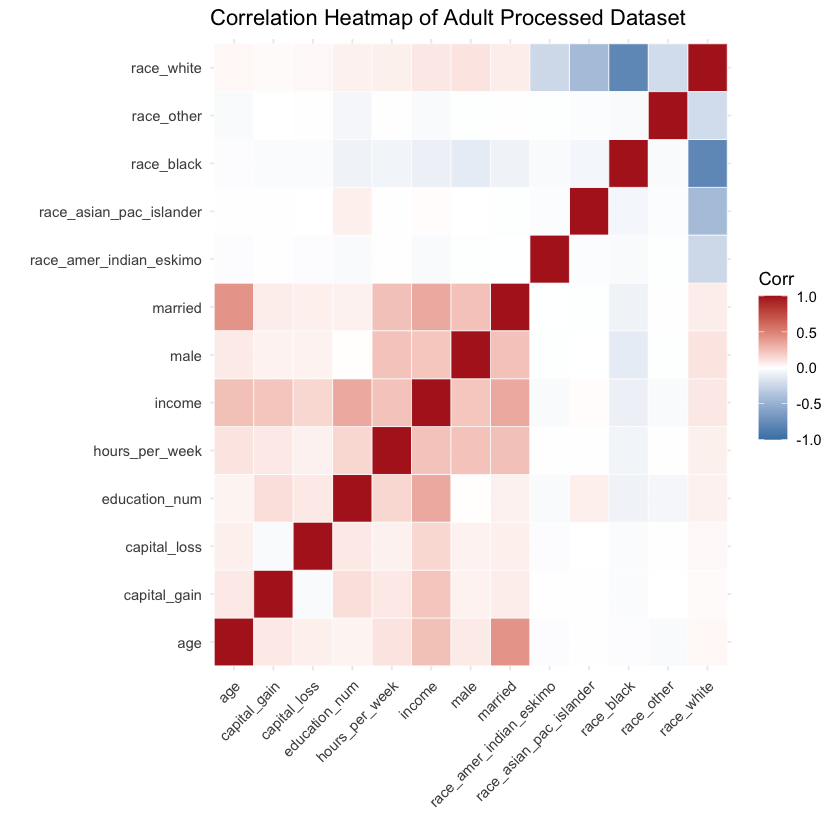

In [6]:
# ---- Correlation heatmap ----
library(dplyr)
library(ggplot2)
library(tidyr)

# 1) Select numeric variables only
num_df <- adult_processed |>
  select(where(is.numeric))

# 2) Compute correlation matrix
cor_mat <- cor(num_df, use = "complete.obs")

# 3) Convert matrix to long format for plotting
cor_long <- as.data.frame(cor_mat) |>
  tibble::rownames_to_column("Var1") |>
  pivot_longer(-Var1, names_to = "Var2", values_to = "Correlation")

# 4) Plot heatmap
ggplot(cor_long, aes(x = Var1, y = Var2, fill = Correlation)) +
  geom_tile(color = "white") +
  scale_fill_gradient2(
    low = "steelblue",
    mid = "white",
    high = "firebrick",
    midpoint = 0,
    limits = c(-1, 1)
  ) +
  theme_minimal() +
  labs(
    title = "Correlation Heatmap of Adult Processed Dataset",
    x = "",
    y = "",
    fill = "Corr"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

We can see there is a skew towards adults that generate an income of <$50,000 in the data set. This means a simple dummy classifier should do quite well on the training set, though likely not out of sample.

Further using the correlation matrix, we can see that the education_num and married variables hold the strongest associations with the response variable income, which we will use to help inform which variables to include in our classification task. We can also see that these two input variables are not highly correlated, which is another positive.

In [7]:
# Simple logistic regression classification

# fit model
model <- glm(income ~ education_num + married,
             data = adult_processed,
             family = binomial())

# predict probabilities
pred_prob <- predict(model, type = "response")

# convert to class predictions (0/1)
pred_class <- ifelse(pred_prob > 0.5, 1, 0)

# simplest accuracy score
accuracy <- mean(pred_class == adult_processed$income)

accuracy

[1] 0.8012731


The downloaded binary packages are in
	/var/folders/dl/21tcjyxx1ln50gqb6s1qqskw0000gn/T//RtmpmKRxHy/downloaded_packages


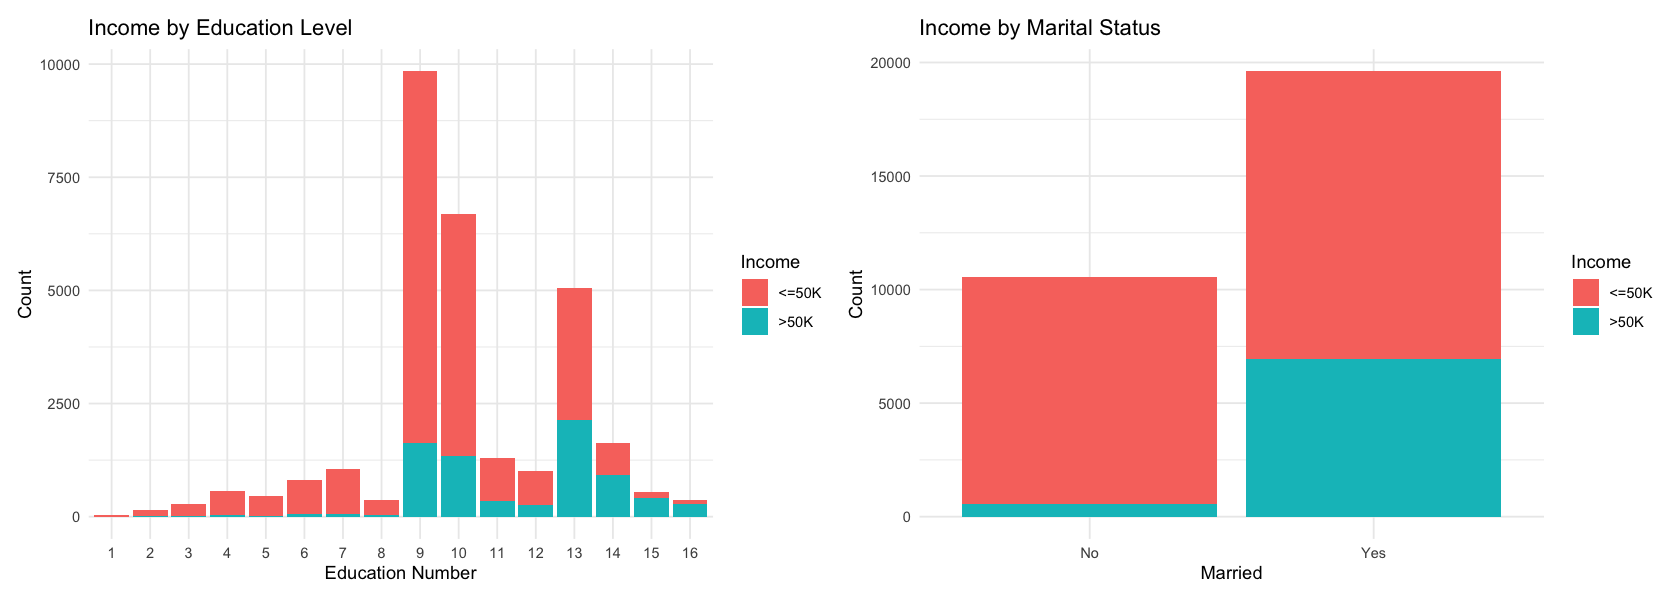

In [8]:
install.packages("patchwork")
library(ggplot2)
library(dplyr)
library(patchwork)

# prepare plotting data
plot_df <- adult_processed |>
  mutate(
    income = factor(income, levels = c(0,1), labels = c("<=50K", ">50K")),
    married = factor(married, levels = c(0,1), labels = c("No", "Yes"))
  )

# ---- Plot 1 ----
p1 <- ggplot(plot_df, aes(x = factor(education_num), fill = income)) +
  geom_bar() +
  labs(
    title = "Income by Education Level",
    x = "Education Number",
    y = "Count",
    fill = "Income"
  ) +
  theme_minimal()

# ---- Plot 2 ----
p2 <- ggplot(plot_df, aes(x = married, fill = income)) +
  geom_bar() +
  labs(
    title = "Income by Marital Status",
    x = "Married",
    y = "Count",
    fill = "Income"
  ) +
  theme_minimal()

# ---- Side-by-side output ----
options(repr.plot.width = 14, repr.plot.height = 5)
p1 + p2

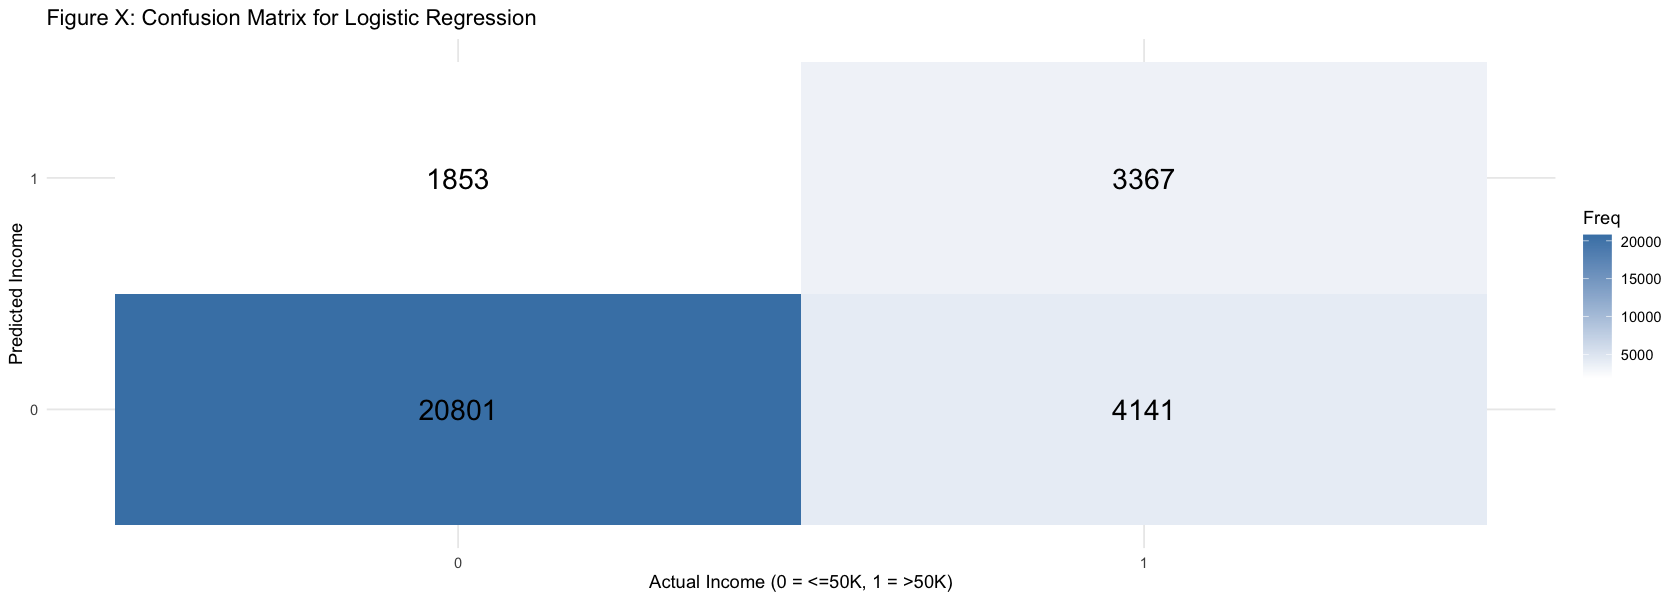

In [ ]:
conf_df$Actual <- factor(conf_df$Actual)
conf_df$Predicted <- factor(conf_df$Predicted)

ggplot(conf_df, aes(x = Actual, y = Predicted, fill = Freq)) +
  geom_tile() +
  geom_text(aes(label = Freq), size = 6) +
  scale_fill_gradient(low = "white", high = "steelblue") +
  labs(
    title = "Confusion Matrix for Logistic Regression",
    x = "Actual Income (0 = <=50K, 1 = >50K)",
    y = "Predicted Income"
  ) +
  theme_minimal()


The downloaded binary packages are in
	/var/folders/dl/21tcjyxx1ln50gqb6s1qqskw0000gn/T//RtmpmKRxHy/downloaded_packages


Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.811

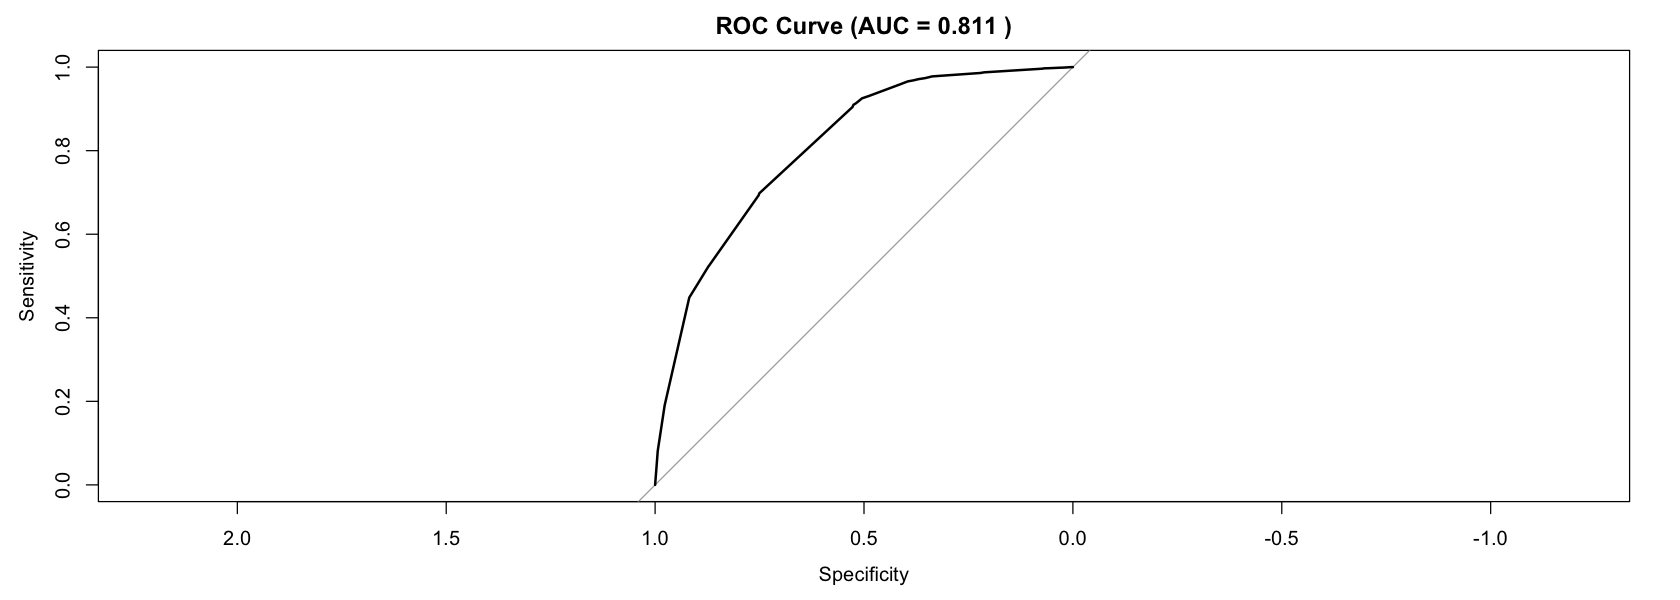

In [14]:
install.packages("pROC")
library(pROC)

roc_obj <- roc(adult_processed$income, pred_prob)

plot(roc_obj,
     main = paste("ROC Curve (AUC =",
                  round(auc(roc_obj), 3), ")"))

auc(roc_obj)

### **Discussion**

We applied a logisitic regression model to predict whether an individual earns \<=$50k or \>$50k a year. The model achived an accuracy of ~80.13% which indicates strong performance. Additionally, Area under the ROC curve (AUC) is equal to 0.811 which suggests that the model has good discriminative ability in distinguishing between individuals earning \<=$50K and \>$50K.

From the exploratory visualiztions, we see that: 

- income increases with education level: individuals with higher education numbers show a noticeably larger proportion of \>$50K earners.

- marital status appears strongly associated with income, with married individuals much more likely to earn above $50,000 compared to unmarried individuals.

The confusion matrix indicates that while the model has a relatively strong performance, it is much better at correctly classifying the individuals with lower incomes (\<=$50k) than individuals with higher incomes (\>$50k). It misclassified 4141 individuals as making <=$50k when in reality they make \>$50k (false negatives). On the other hand it misclassified 1853 individuals as making \>$50k when in reality them make \<=$50k (false positives). This shows that the model is more comfortable labelling lower income groups compared to higher income ones. 

The increase in income with higher education level corresponds well with human capital theory, which also suggests "educational level is positively correlated with income" (Strober, 1990, p. 214). Therefore, it is not surprising that individuals with higher education numbers are more likely to earn above $50,000.

A previous study has shown that there can be a "hypothetical
positive effect of the marriage on income" (Cutright, 1970, p.636). This somewhat consistent with our finding which shows a positive association between marriage and income. 

The model’s stronger performance in predicting \<=$50K earners was somewhat expected due to class imbalance in salary dataset, where the lower-income group has a much larger population.Therefore, it is not surprising that individuals with higher education numbers are more likely to earn above $50,000.

Potential implications of our model:

- **Education and Policy**: The strong link between education and income highlights the importance of educational access. Investments in education can contribute to long-term income growth.

- __Predictive Modeling Applications__: With an AUC of 0.811, the model demonstrates practical predictive value. Similar models could be used in other economic research.

Future questions that arise from our model:

- Would more complex models (e.g., random forests or gradient boosting) improve detection of high-income earners?
- How can class imbalance be addressed?
- Does the model perform equally well across gender, race, or age groups? 







### **References**

STROBER, MYRA H. “Human Capital Theory: Implications for HR Managers.” Industrial Relations, vol. 29, no. 2, Mar. 1990, pp. 214–239.

Cutright, Phillips. “Income and Family Events: Getting Married.” Journal of Marriage and the Family, vol. 32, no. 4, Nov. 1970, p. 628, https://doi.org/10.2307/350256. Accessed 3 Dec. 2019.
